## Luís Forti - 3981932
## Marcell Slyuch - 3992616

# CV - Image Classification Lab

Note that this lab has three levels: basic, regular and advanced.


Doing the **basic** part earns you a grade of 5.5-6.0.

Doing the **regular** part earns you a max grade of 8.0.

Doing the **advanced** part earns you a max grade of 10.0.

Please return a Jupyter notebook as a submission in Canvas, this makes grading easier for us.

<font color="red" size="4" face="Arial">As you go through the exercises, you'll encounter various example outputs. Use these as references while navigating the assignment. However, matching these exact values or neural network structures isn't the primary objective. You're encouraged to adjust the parameters as needed, ensuring they remain relevant and appropriate for the task at hand.</font>


## Basic Level
In this part, we will attempt a binary classification problem using a DNN and a CNN.

We will then proceed to change our network architectures to solve a multiclassification problem.

The dataset used consists of medical images of breast cancer using ultrasound scan.

The images are categorized into three classes, which are **normal**, **benign**, and **malignant**.

### Necessary imports

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os
import os.path
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt
import keras
from keras.utils import to_categorical 
import random
from sklearn.metrics import confusion_matrix
from scipy.special import softmax
from keras.layers import LeakyReLU
from sklearn.utils import shuffle
from keras.layers import  Input, Dense, BatchNormalization, Conv2D
from keras import layers
from keras.layers import Input, Dense, Activation,BatchNormalization, Flatten, Conv2D, MaxPooling2D
from keras.models import Model
from keras.preprocessing import image
import keras.backend as K

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
folder = 'Assignment_Dataset'
rs=1
ts=0.25

### Exercise 1
The directory above contains the dataset for this week's assignment. 

You'll find three folders within it, **normal** ,**malignant** and **benign**.
Load the images within the three folders, with the appropriate labels (the images within the folder **malignant** should be labelled with **malignant**, same goes for **benign** and **normal**).
One way to do this, is to load the images in one list, and load the labels (corresponding to the name of the folder you load the scans from) in another list.

Note also that we're working with a small dataset. 

In [4]:
images = []
labels = []

for label in ['normal', 'malignant', 'benign']:
    path = os.path.join(folder, label)

    for filename in tqdm(os.listdir(path), desc=label):
        filepath = os.path.join(path, filename)

        try:
            img = Image.open(filepath)
            images.append(img)
            labels.append(label)
        except:
            pass

benign: 100%|██████████| 437/437 [00:00<00:00, 8755.46it/s]


In [5]:
print("In all folders, we have", len(images),"images","and ", len(labels), "corresponding labels")
print(pd.Series(labels).value_counts())

In all folders, we have 780 images and  780 corresponding labels
benign       437
malignant    210
normal       133
Name: count, dtype: int64


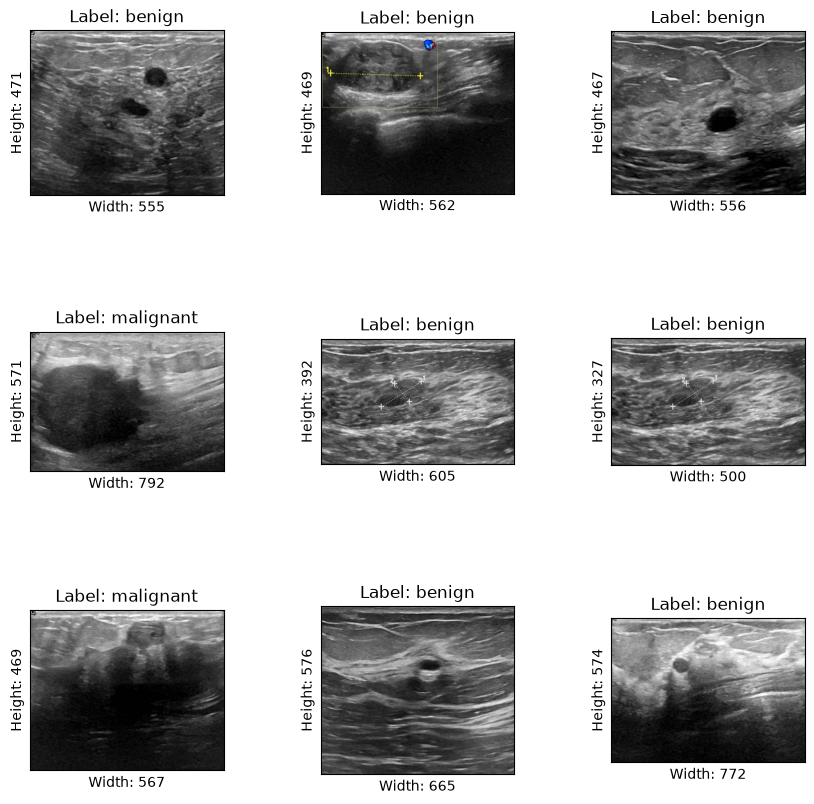

In [6]:
vis_images, vis_label = shuffle(images, labels)
plt.figure(figsize=(10, 10))
for i in range(1, 10):  
    plt.subplot(3, 3, i)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.imshow(vis_images[i-1])
    plt.title(f'Label: {vis_label[i-1]}', fontsize=12)
    width, height = vis_images[i-1].size
    plt.xlabel(f'Width: {width}', fontsize=10)
    plt.ylabel(f'Height: {height}', fontsize=10)
    plt.xticks([])
    plt.yticks([])
plt.show()


### Exercise 2
Write a function **convert(dataset, target_mode)** that will take your list of images and convert them from their current mode RGB, to the target mode **L** (grayscale)

In [7]:
print("The current mode of the images in the dataset is",images[0].mode)

The current mode of the images in the dataset is RGB


In [8]:
def convert(dataset, mode): 
    converted = []

    for img in tqdm(dataset):
        converted.append(img.convert(mode))
    return converted        

In [9]:
images=convert(images, 'L')

100%|██████████| 780/780 [00:04<00:00, 182.95it/s]


In [10]:
print("Image mode is now",images[0].mode)

Image mode is now L


### Exercise 3
It turns out that the images in our dataset are not of the same size. 
Write a function **check_size(dataset)**, which inputs your dataset of images and returns True if all images are of the same size and False otherwise.

In [11]:
def check_size(dataset):
    first_size = dataset[0].size

    for img in dataset:
        if img.size != first_size:
            return False
    return True

In [12]:
print("All images are of the same size:",check_size(images))

All images are of the same size: False


### Exercise 4
Write a function **resize(dataset, size)**, to which you pass your dataset and a tuple (h, w). Your function should output the dataset with all the images in the same size.

In [13]:
def resize(dataset, size):
    resized = []

    for img in tqdm(dataset):
        resized.append(img.resize((size[1], size[0])))

    return resized

In [14]:
resized_images=resize(images, (64,64))

100%|██████████| 780/780 [00:00<00:00, 2531.32it/s]


In [15]:
print("All images are of the same size:",check_size(resized_images))

All images are of the same size: True


In [16]:
print(type(images[0]))

<class 'PIL.Image.Image'>


### Exercise 5
Recall that a model cannot be trained on an Image object, we need first to convert our dataset of images into a dataset of numpy arrays, in which every array is the representation of an image.

Write a function **to_npArray(dataset)**, which will input your images dataset and return the dataset with the images converted to numpy arrays.

In [17]:
def to_npArray(dataset):
    np_dataset = []

    for img in tqdm(dataset):
        np_dataset.append(np.array(img))

    return np_dataset

In [18]:
np_images=to_npArray(resized_images)

100%|██████████| 780/780 [00:00<00:00, 80546.50it/s]


In [19]:
np_images=np.array(np_images)

In [20]:
np_images.shape

(780, 64, 64)

#### You can see now that our dataset has 780 examples, each example is of the shape (h,w). In our case here (64,64). Feel free to resize your images to the values you see fit. Keep in mind that a higher size means more features, slower training, and a risk of overfitting.

### Exercise 6
Pixel values in our grayscale images might go up to 255, when calculating sigmoid of such values (multiplied by their respective weights), we might end up with overflow issues.
One way to solve this problem is by feature scaling.
You can use sklearn's [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) to scale the features in your dataset. You can also implement your own scaler, by simply dividing all the values in your dataset by the max value.

In [21]:
def scale(dataset):
    return np.array(dataset) / 255.0

In [22]:
np_images = scale(np_images)
print(np_images[0])

[[0.38823529 0.34117647 0.69019608 ... 0.70196078 0.70980392 0.66666667]
 [0.3372549  0.41960784 0.65882353 ... 0.71764706 0.78823529 0.7372549 ]
 [0.39215686 0.5254902  0.59607843 ... 0.87843137 0.77647059 0.62745098]
 ...
 [0.08235294 0.06666667 0.08235294 ... 0.08235294 0.08627451 0.09019608]
 [0.07843137 0.07058824 0.0745098  ... 0.08627451 0.08627451 0.09019608]
 [0.07843137 0.07843137 0.09019608 ... 0.09019608 0.07843137 0.08235294]]


## Binary classification 
We'll start by doing a binary classification problem.

In later exercises, we will shift back to treating the multiclassification problem the dataset suggests.
### Exercise 7

We are now preparing our dataset for binary classification. While our dataset contains three classes - **benign**, **malignant**, and **normal** - our initial model will categorize the scans as either **0** (malignant) or **1** (either normal or benign). We'll formulate a 'y' vector where the '**malignant**' label is encoded as **0**, and the other labels are encoded as **1**.

In [23]:
def binary_labels(labels):
    y = []

    for label in tqdm(labels):
        if label == 'malignant':
            y.append(0)
        else:
            y.append(1)

    return np.array(y)

In [24]:
y = binary_labels(labels)
print(y.shape)

100%|██████████| 780/780 [00:00<00:00, 519872.42it/s]

(780,)


### Exercise 8

For this task, you'll employ **Keras** to construct your neural network. We've shown in the lecture how straightforward it is to design DNNs with Keras: all you need to do is outline your network's structure and let Keras do the heavy lifting.

The lecture's demonstration assumes that images have been flattened before they are fed into the Keras DNN. This means the dataset will have a shape like (ne, w, h). Given our dataset with **780 samples** and an image size of (64 , 64), when you flatten these images, they will reshape the dataset to (780, 4096).

Keras can also handle the flattening for you. So, you can supply the dataset in the shape (780, 64, 64) and Keras will take care of reshaping before starting the model's training.

a. Reshape your dataset to what Keras expects

In [25]:
def reshape_dataset(dataset):
    return np.array(dataset).reshape(len(dataset), -1)

In [26]:
np_images_flattened = reshape_dataset(np_images)
np_images_flattened.shape

(780, 4096)

In [27]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

b. Create your model and compile it in the cell below

In [28]:
model = keras.Sequential([
    keras.layers.Input(shape=(train_X.shape[1],)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 256)               1048832   
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1090049 (4.16 MB)
Trainable params: 1090049 (4.16 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


c. Fit the model to the data below

In [30]:
history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    epochs=250,
    batch_size=32
)

Epoch 1/250


19/19 [==============================] - 1s 17ms/step - loss: 0.6303 - accuracy: 0.7231 - val_loss: 0.6077 - val_accuracy: 0.7538
Epoch 2/250
19/19 [==============================] - 0s 9ms/step - loss: 0.6155 - accuracy: 0.7231 - val_loss: 0.5912 - val_accuracy: 0.7538
Epoch 3/250
19/19 [==============================] - 0s 9ms/step - loss: 0.6047 - accuracy: 0.7231 - val_loss: 0.5812 - val_accuracy: 0.7538
Epoch 4/250
19/19 [==============================] - 0s 9ms/step - loss: 0.5987 - accuracy: 0.7231 - val_loss: 0.5741 - val_accuracy: 0.7538
Epoch 5/250
19/19 [==============================] - 0s 9ms/step - loss: 0.5943 - accuracy: 0.7231 - val_loss: 0.5695 - val_accuracy: 0.7538
Epoch 6/250
19/19 [==============================] - 0s 9ms/step - loss: 0.5920 - accuracy: 0.7231 - val_loss: 0.5655 - val_accuracy: 0.7538
Epoch 7/250
19/19 [==============================] - 0s 9ms/step - loss: 0.5900 - accuracy: 0.7231 - val_loss: 0.5639 - val_accuracy: 0.7538
Epoch 8/25

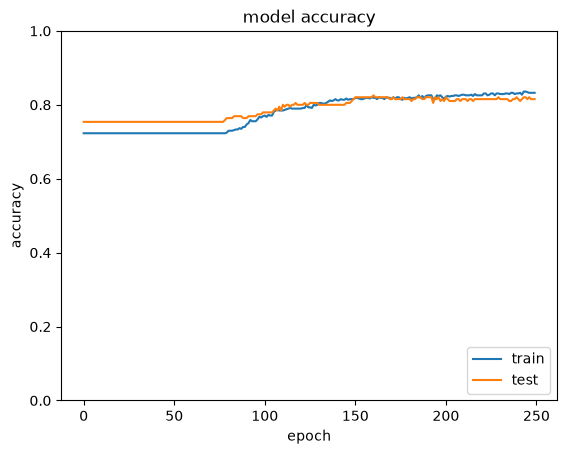

In [31]:
# visualise training history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.ylim(0, 1)
plt.show()

d. Print the accuracy of your model on the train and test set

In [32]:
train_loss, train_accuracy = model.evaluate(train_X, train_y, verbose=0)
test_loss, test_accuracy = model.evaluate(test_X, test_y, verbose=0)

print(f"Train accuracy: {train_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Train accuracy: 83.25%
Test accuracy: 81.54%


e. Update (by simply rerunning the cell) the confusion matrix below to check how good your model has done on the data.

7/7 [==============================] - 0s 2ms/step


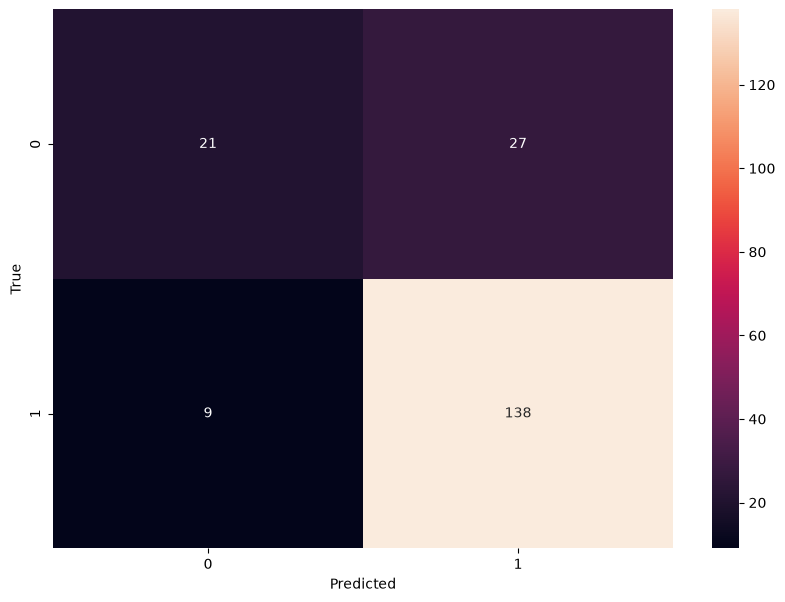

In [33]:
predictions = model.predict(test_X)
predicted_labels = (predictions > 0.5).astype("int32")
cm = confusion_matrix(test_y, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Exercise 9
Let's now try the same thing with a CNN and see whether we can improve on the results we get.
You're free to try any CNN architecture you wish. Keep in mind that a high number of layers and of filters in these layers makes the number of parameters grow, and makes the learning duration longer.

In [34]:
train_X, test_X, train_y, test_y = train_test_split(np_images, y, test_size=ts, shuffle=True, random_state=rs)

a. Create and compile your model architecture below

In [35]:
model = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 1)),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [36]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 128)        

b. Fit your CNN to the data

In [37]:
history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    epochs=250,
    batch_size=32
)

Epoch 1/250
19/19 [==============================] - 2s 38ms/step - loss: 0.6811 - accuracy: 0.5949 - val_loss: 0.6545 - val_accuracy: 0.7538
Epoch 2/250
19/19 [==============================] - 1s 30ms/step - loss: 0.6444 - accuracy: 0.7265 - val_loss: 0.6171 - val_accuracy: 0.7538
Epoch 3/250
19/19 [==============================] - 1s 30ms/step - loss: 0.6170 - accuracy: 0.7231 - val_loss: 0.5912 - val_accuracy: 0.7538
Epoch 4/250
19/19 [==============================] - 1s 31ms/step - loss: 0.6011 - accuracy: 0.7231 - val_loss: 0.5708 - val_accuracy: 0.7538
Epoch 5/250
19/19 [==============================] - 1s 31ms/step - loss: 0.5854 - accuracy: 0.7231 - val_loss: 0.5562 - val_accuracy: 0.7538
Epoch 6/250
19/19 [==============================] - 1s 31ms/step - loss: 0.5783 - accuracy: 0.7231 - val_loss: 0.5476 - val_accuracy: 0.7538
Epoch 7/250
19/19 [==============================] - 1s 31ms/step - loss: 0.5731 - accuracy: 0.7231 - val_loss: 0.5423 - val_accuracy: 0.7538
Epoch 

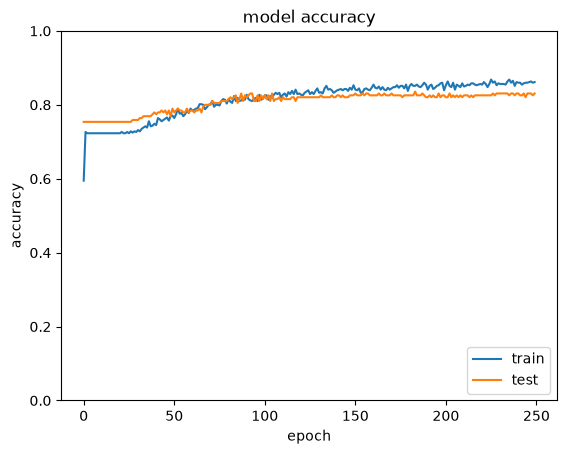

In [38]:
# visualise training history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0, 1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

c. Print your model's accuracy on the test and train sets

In [39]:
train_loss, train_accuracy = model.evaluate(train_X, train_y, verbose=0)
test_loss, test_accuracy = model.evaluate(test_X, test_y, verbose=0)

print(f"Train accuracy: {train_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Train accuracy: 86.15%
Test accuracy: 83.08%


d. Create a confusion matrix to inspect the model's output

7/7 [==============================] - 0s 8ms/step


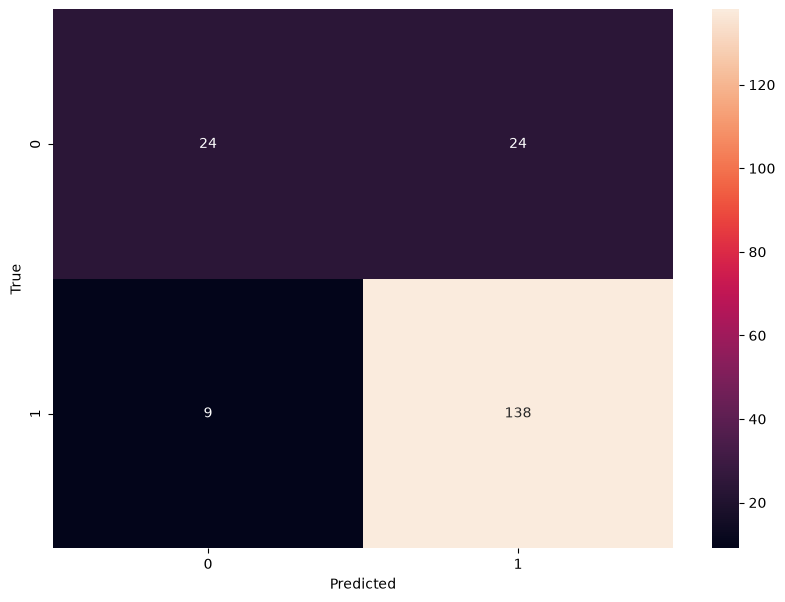

In [40]:
predictions = model.predict(test_X)
predicted_labels = (predictions > 0.5).astype("int32")
cm = confusion_matrix(test_y, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Turns out my CNN architecture underperforms against my DNN. Depending on how your CNNs architecture and parameters are, you might get better results.

## Multiclassification
Let's now shift back to building models that can distinguish the three classes, and not just segregate the **normal** scans from the other scans.

Our first task is to encode our **y** vector properly. 
Keep also in mind that the **sigmoid** activation is not the right choice for the output layer, and that the number of neurons of the output layer needs to be equal to the number of expected classes.

### Exercise 10
Create a **y** matrix for your labels. The **y** matrix is of shape **(ne, nc)**. 

With **ne** meaning number of examples and **nc** meaning number of possible classes.

Refer to keras' to_categorical() function to create your ground truth matrix.

In [41]:
y = to_categorical(
    [0 if label == 'malignant' else 1 if label == 'benign' else 2 for label in labels],
    num_classes=3
)

In [42]:
y.shape

(780, 3)

### Exercise 11


In [43]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

a. You can now create another DNN to classify your scans according to their labels.

In [44]:
model = keras.Sequential([
    keras.layers.Input(shape=(train_X.shape[1],)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.05),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.05),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 4096)              0         
                                                                 
 dense_6 (Dense)             (None, 128)               524416    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                      

b. Train your model below

In [46]:
history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    epochs=250,
    batch_size=32
)

Epoch 1/250
19/19 [==============================] - 1s 15ms/step - loss: 1.1075 - accuracy: 0.4154 - val_loss: 1.0511 - val_accuracy: 0.4821
Epoch 2/250
19/19 [==============================] - 0s 7ms/step - loss: 1.0012 - accuracy: 0.5009 - val_loss: 1.0384 - val_accuracy: 0.5231
Epoch 3/250
19/19 [==============================] - 0s 7ms/step - loss: 0.9309 - accuracy: 0.5607 - val_loss: 1.0252 - val_accuracy: 0.5487
Epoch 4/250
19/19 [==============================] - 0s 7ms/step - loss: 0.9054 - accuracy: 0.5761 - val_loss: 1.0150 - val_accuracy: 0.5590
Epoch 5/250
19/19 [==============================] - 0s 6ms/step - loss: 0.8795 - accuracy: 0.6085 - val_loss: 1.0059 - val_accuracy: 0.5744
Epoch 6/250
19/19 [==============================] - 0s 7ms/step - loss: 0.8236 - accuracy: 0.6308 - val_loss: 0.9958 - val_accuracy: 0.6000
Epoch 7/250
19/19 [==============================] - 0s 7ms/step - loss: 0.8305 - accuracy: 0.6376 - val_loss: 0.9873 - val_accuracy: 0.6000
Epoch 8/250


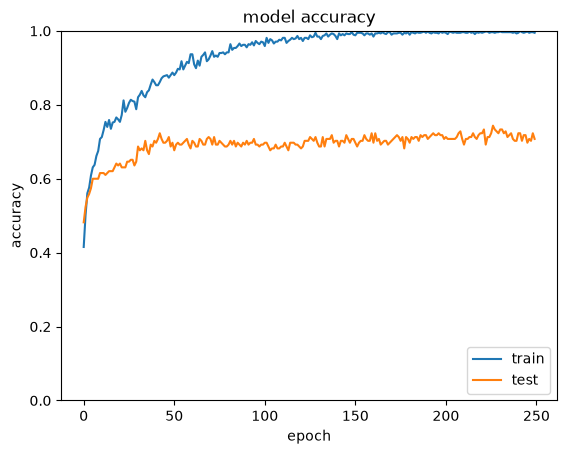

In [47]:
# visualise training history
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

The use of the dropout layers did not prevent the model from memorizing the data. 

The network architecture I used is complex and the training dataset is too small.

c. Print your model's accuracy on the test and train sets

In [48]:
train_loss, train_accuracy = model.evaluate(train_X, train_y, verbose=0)
test_loss, test_accuracy = model.evaluate(test_X, test_y, verbose=0)

print(f"Train accuracy: {train_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Train accuracy: 99.83%
Test accuracy: 70.77%


d. Create a confusion matrix to inspect the model's output

7/7 [==============================] - 0s 2ms/step


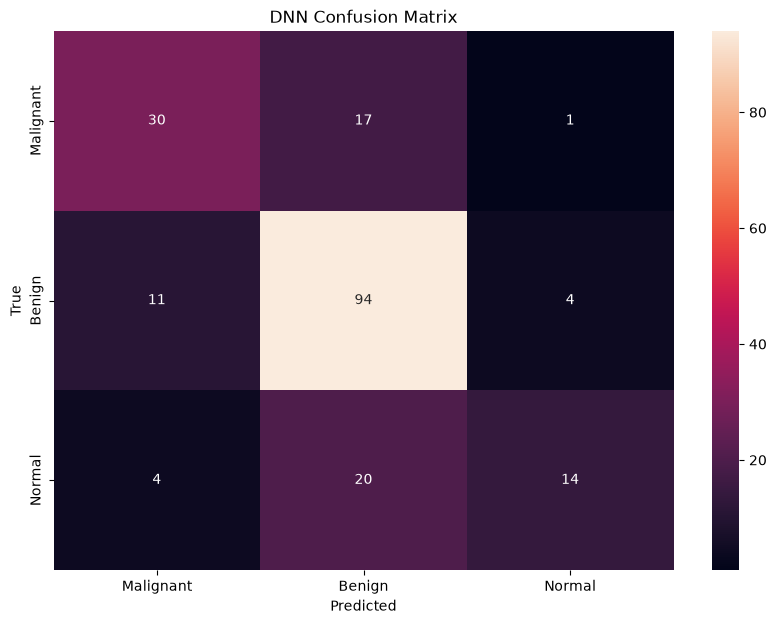

In [49]:
predictions = model.predict(test_X)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_y, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    xticklabels=['Malignant', 'Benign', 'Normal'],
    yticklabels=['Malignant', 'Benign', 'Normal']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DNN Confusion Matrix')
plt.show()

### Exercise 12
Use Keras again to build and train a new CNN to classify the scans into three the three classes.

In [50]:
train_X, test_X, train_y, test_y = train_test_split(np_images, y, test_size=ts, shuffle=True, random_state=rs)

a. Create your CNN's architecture and compile it

In [51]:
model = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 1)),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 62, 62, 32)        320       
                                                                 
 batch_normalization_1 (Bat  (None, 62, 62, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 31, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 batch_normalization_2 (Bat  (None, 29, 29, 64)        256       
 chNormalization)                                                
                                                      

b. Fit your model to the data

In [53]:
history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    epochs=250,
    batch_size=32
)

Epoch 1/250
19/19 [==============================] - 2s 50ms/step - loss: 1.6923 - accuracy: 0.4974 - val_loss: 1.3170 - val_accuracy: 0.2462
Epoch 2/250
19/19 [==============================] - 1s 41ms/step - loss: 0.8579 - accuracy: 0.6291 - val_loss: 1.7573 - val_accuracy: 0.2462
Epoch 3/250
19/19 [==============================] - 1s 41ms/step - loss: 0.6570 - accuracy: 0.7145 - val_loss: 2.1768 - val_accuracy: 0.2462
Epoch 4/250
19/19 [==============================] - 1s 41ms/step - loss: 0.5459 - accuracy: 0.7744 - val_loss: 2.5202 - val_accuracy: 0.2462
Epoch 5/250
19/19 [==============================] - 1s 41ms/step - loss: 0.4470 - accuracy: 0.8085 - val_loss: 2.7314 - val_accuracy: 0.2462
Epoch 6/250
19/19 [==============================] - 1s 41ms/step - loss: 0.3914 - accuracy: 0.8496 - val_loss: 3.2435 - val_accuracy: 0.2462
Epoch 7/250
19/19 [==============================] - 1s 42ms/step - loss: 0.3265 - accuracy: 0.8735 - val_loss: 3.2402 - val_accuracy: 0.2462
Epoch 

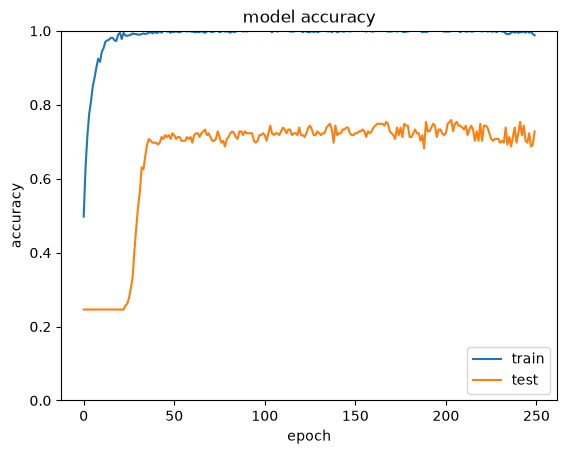

In [54]:
# visualise training history
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Same overfitting pattern exhibited by the CNN architecture and parameters I used.

c. Check the performance of your model

In [55]:
train_loss, train_accuracy = model.evaluate(train_X, train_y, verbose=0)
test_loss, test_accuracy = model.evaluate(test_X, test_y, verbose=0)

print(f"Train accuracy: {train_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Train accuracy: 100.00%
Test accuracy: 72.82%


d. Create a confusion matrix to inspect the model's output

7/7 [==============================] - 0s 11ms/step


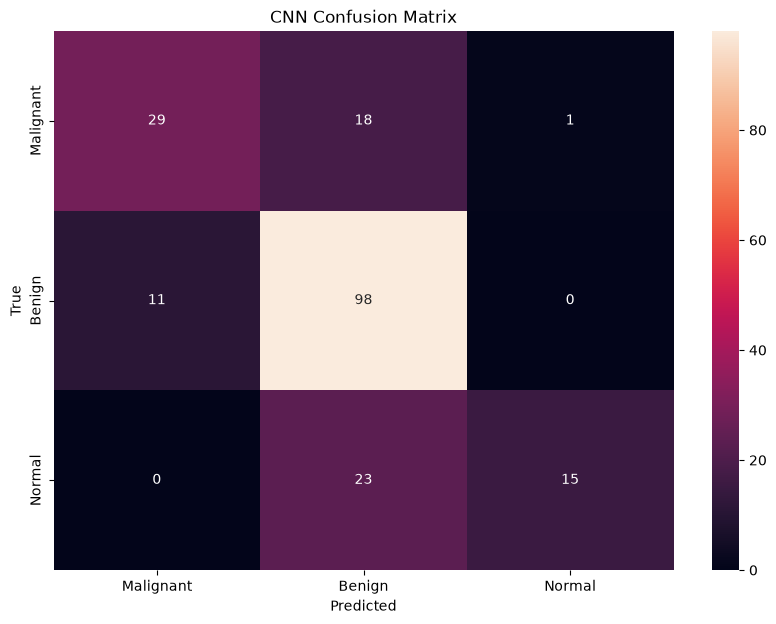

In [56]:
predictions = model.predict(test_X)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_y, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    xticklabels=['Malignant', 'Benign', 'Normal'],
    yticklabels=['Malignant', 'Benign', 'Normal']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.show()

### Optional Exercise
Both models for multiclassification overfit. This can be caused by the high complexity of the networks that we have used, it could also be due to the low number of training examples we have (around 600 used for training+ an imbalanced dataset).

Refer to this data augmentation technique suggested by Keras [Image Data Generator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator), and check whether it can help bridge the gap between the accuracy in training and the accuracy of the test set.


In [57]:
#This part is optional
#Try data augmentation to reduce overfitting, or add dropout layers to your neural network

### Regular Level
In this part, we wish to implement our own deep learning network for binary classification.
### Exercise 13
To test the functions, let's use a network of the dimensions [64 x 64, 128,64,1]

We'll first write the function initialize(network_dims), which will initialize the weights and biases of our network.

a. Copy your **y** vector of binary classification (not the one hot-encoded matrix)

In [101]:
y = binary_labels(labels)
print(y.shape)

100%|██████████| 780/780 [00:00<?, ?it/s]

(780,)


In [102]:
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

In [103]:
def initialize(network_dims):
    params = {}
    L = len(network_dims)
    for l in range(1, L):
        params['W' + str(l)] = np.random.randn(network_dims[l], network_dims[l - 1])
        params['b' + str(l)] = np.random.randn(network_dims[l], 1)

    return params

In [104]:
params=initialize([train_X.shape[1], 128,64, 1])

In [105]:
print('shape of W1', params['W1'].shape)
print('shape of b1', params['b1'].shape)
print('shape of W2', params['W2'].shape)
print('shape of b2', params['b2'].shape)
print('shape of W3', params['W3'].shape)
print('shape of b3', params['b3'].shape)

shape of W1 (128, 4096)
shape of b1 (128, 1)
shape of W2 (64, 128)
shape of b2 (64, 1)
shape of W3 (1, 64)
shape of b3 (1, 1)


You are now requested to implement the forward_pass(X, params), which takes your training set X as input and returns the activations of the hidden and final layer.
Your function should implement the following functions:

$$Z^{[l]}=W^{[l]}.A^{[l-1]}+b^{[l]}$$
$$A^{[l]}=\sigma Z^{[l]}$$

You of course need to iterate over the layers of your model (hidden and final/output layer).


In [106]:
def forward_pass(X, params):
    activations = {'A0': X}
    A = X

    L = len(params) // 2

    for l in range(1, L + 1):
        W = params['W' + str(l)]
        b = params['b' + str(l)]

        Z = np.dot(W, A) + b
        A = 1 / (1 + np.exp(-Z))

        activations['A' + str(l)] = A

    return activations

In [107]:
#recall that X in our scenario is of shape (nf, ne)
train_X=train_X.T

In [108]:
activations=forward_pass(train_X, params)

In [109]:
print("The shape of the activation of the first layer",activations['A1'].shape)
print("The shape of the activation of the second layer",activations['A2'].shape)
print("The shape of the activation of the output layer",activations['A3'].shape)

The shape of the activation of the first layer (128, 585)
The shape of the activation of the second layer (64, 585)
The shape of the activation of the output layer (1, 585)


### Exercise 14
We get now to implementing our gradient descent.

Write a function gradient_descent(params, activations, y, lr), which input your parameters, the activations of your forward_pass, your ground truth vector y and your learning_rate lr. 

The function needs to implement the following equations:

$$dZ^{[fl]}=A^{[fl]}-y$$
$$dZ^{[l-1]}=W^{[l]}T .dZ^{[l]} * A^{[l-1]}(1-A^{[l-1]})$$
$$dW^{[l]}=\frac {1}{ne} (dZ^{[l]}.A^{[l-1]}T)$$
$$dW^{[l]}=\frac {1}{ne} \sum dZ^{[l]} $$
$$W=W-\alpha dW$$

$$W=b-\alpha db$$



In [110]:
def gradient_descent(activations, params, y, lr):
    L = len(params) // 2
    ne = activations['A0'].shape[1]

    grads = {}

    #Calculate all gradients first
    for l in range(L, 0, -1):
        A_prev = activations['A' + str(l - 1)]
        A = activations['A' + str(l)]

        if l == L:
            dZ = A - y
        else:
            W_next = params['W' + str(l + 1)]
            dZ = np.dot(W_next.T, dZ) * A * (1 - A)

        grads['W' + str(l)] = (1 / ne) * np.dot(dZ, A_prev.T)
        grads['b' + str(l)] = (1 / ne) * np.sum(dZ, axis=1, keepdims=True)

    #Update all parameters
    for l in range(1, L + 1):
        params['W' + str(l)] -= lr * grads['W' + str(l)]
        params['b' + str(l)] -= lr * grads['b' + str(l)]

    return params

In [111]:
params=gradient_descent(activations, params, train_y, lr=0.5)

In [112]:
print('shape of W1', params['W1'].shape)
print('shape of b1', params['b1'].shape)
print('shape of W2', params['W2'].shape)
print('shape of b2', params['b2'].shape)
print('shape of W3', params['W3'].shape)
print('shape of b3', params['b3'].shape)

shape of W1 (128, 4096)
shape of b1 (128, 1)
shape of W2 (64, 128)
shape of b2 (64, 1)
shape of W3 (1, 64)
shape of b3 (1, 1)


### Exercise 15
Now we can implement our dnn model in 3 simple steps
1. initialize the matrices W and the bias vectors b
2. repeat until number of iterations is reached 
    2.1. get your matrices of activations
    2.2. update the weights W and biases b using gradient descent
3. return the final matrices for  W and bias vectors b

dnn(X, y, network_dims, lr, iters), takes the matrix X as an input, the vector of true labels y, network dimensions, a learning rate, and the number of iterations iters. The function returns the learned parameters of the model, namely W and b.


In [113]:
def dnn(X, y, network_dims, lr, iters):
    params = initialize(network_dims)
    
    for i in tqdm(range(iters)):
        activations = forward_pass(X, params)
        params = gradient_descent(activations, params, y, lr)
    
    return params

In [118]:
params=dnn(train_X, train_y, network_dims = [train_X.shape[0], 64, 32,1 ], lr = 0.75, iters = 50)

100%|██████████| 50/50 [00:00<00:00, 97.37it/s]


In [119]:
def predict(X, params):
    activations = forward_pass(X, params)
    L = len(params) // 2
    Af = activations['A' + str(L)]
    return  1*(Af>=0.5)

In [120]:
predictions=predict(test_X.T, params)

In [121]:
print("Accuracy on our test set is", accuracy_score(test_y.flatten(), predictions.flatten())*100, "%")

Accuracy on our test set is 76.92307692307693 %


#### Quite a good result actually.

## Advanced Level
We said in the lecture that a sigmoid activated neurone predicts values between 0 and 1, making it adequate for binary classification.

We also said that a softmax activation function is suitable for multiclassification.
To change our code above and make it capable of doing multiclassification, we need to implement the softmax function.
We also said that the log_loss isn't useful in this case, we will instead use cross entropy loss.

We also said that **dZL** (L for final layer) remains the same as before.

Your task is to modify the code you implemented above to handle the same multiclassification problem you handled with Keras.

We are not interested in a completely new implementation, we expect that you will modify one of your functions above and adapt the code to handle the new type of classification (multiclass).

In [122]:
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


def forward_pass_multiclassification(X, params):
    activations = {'A0': X}
    A = X

    L = len(params) // 2

    for l in range(1, L + 1):
        W = params['W' + str(l)]
        b = params['b' + str(l)]

        Z = np.dot(W, A) + b

        if l == L:
            #Final layer: softmax for multiclass classification
            A = softmax(Z)
        else:
            #Hidden layers: sigmoid
            A = 1 / (1 + np.exp(-Z))

        activations['A' + str(l)] = A

    return activations

In [123]:
def dnn_2(X, y, network_dims, lr, iters):
    params = initialize(network_dims)

    for i in tqdm(range(iters)):
        activations = forward_pass_multiclassification(X, params)
        
        params = gradient_descent(activations, params, y, lr)
    return params

In [124]:
y = to_categorical(
    [0 if label == 'malignant' else 1 if label == 'benign' else 2 for label in labels],
    num_classes=3
)
train_X, test_X, train_y, test_y = train_test_split(np_images_flattened, y, test_size=ts, shuffle=True, random_state=rs)

In [125]:
params = dnn_2(train_X.T, train_y.T, network_dims=[train_X.shape[1], 64, 4, 3], lr=0.005, iters=500)

100%|██████████| 500/500 [00:04<00:00, 107.42it/s]


In [126]:
def predict(X, params):
    activations = forward_pass_multiclassification(X, params)
    C = len(params) // 2
    Af = activations['A' + str(C)]
    return np.argmax(Af, axis=0) 

In [127]:
predictions=predict(test_X.T, params)

In [128]:
true_labels = np.argmax(test_y, axis=1)

print("Accuracy on our test set is", accuracy_score(true_labels, predictions) * 100, "%")

Accuracy on our test set is 57.43589743589743 %


The performance isn't as strong as the Keras models.

In the advanced CV lecture, you'll explore transfer learning, a technique that enables us to repurpose a pre-trained model for classifying different objects and adapt it to identify cancer scans. This method is especially beneficial when the training dataset is limited, and will allow us to improve the accuracy of our cancer detection model.

#### Hope you enjoyed working with DNNs and CNNs